ML Case Study
Please use Python for the following. Document your steps and state any assumptions you make. A single Jupyter notebook file (.ipynb) with your approach and code is sufficient. Make sure it is commented and easy to follow. If you prefer, you can submit a text document with your analysis too. 
The data for the case study comes from the Census Income data set in the UCI Machine Learning Repository. Your objective is to predict whether income of an individual exceeds $50K/per year based on census data. More importantly the objective for you is to demonstrate how you tackle a traditional supervised learning problem.
1)	Download the data from the following link http://archive.ics.uci.edu/ml/datasets/Adult into Python.
2)	Read the Attribute Information from the web page. More information can be found in the Data Set Description.
3)	Be sure to document your steps and your rationale behind each one of them. This is best done with Jupyter notebook or a word document.
4)	Predict the class variable using the given attributes. Use two supervised learning methods. Avoid over-fitting.
5)	 Assess the performance of your models using appropriate metrics. Discuss which model is best and why.
6)	Please provide an explanation in plain English of the business problem you were trying to solve and your analysis of the outcomes.  Please add any supporting visualizations to support your explanation.
7)	This is intentionally left somewhat open-ended. We want to see how you approach the problem.

Please Note: We expect you to approach this business problem with honesty and integrity and rely on your knowledge of machine learning. Please do not copy from any web-based repository. Candidates will be disqualified if we notice attempts of plagiarism.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os



In [2]:
folder_path = os.getcwd()
file_path ="/adult/adult.csv"
full_file_path = folder_path+file_path
print("Full File Path = ", full_file_path)

adult_df = pd.read_csv(full_file_path)
adult_df.head()

print(adult_df.columns)


Full File Path =  /Users/chandra/Desktop/FSDS_GenAI_Training/FSDS_Classes/Python_Workspace/ML/THOMPSON_REUTER_homework/adult/adult.csv
Index(['39', ' State-gov', ' 77516', ' Bachelors', ' 13', ' Never-married',
       ' Adm-clerical', ' Not-in-family', ' White', ' Male', ' 2174', ' 0',
       ' 40', ' United-States', ' <=50K'],
      dtype='object')


# The columns names are missing, so adding them

In [3]:
adult_df.columns

Index(['39', ' State-gov', ' 77516', ' Bachelors', ' 13', ' Never-married',
       ' Adm-clerical', ' Not-in-family', ' White', ' Male', ' 2174', ' 0',
       ' 40', ' United-States', ' <=50K'],
      dtype='object')

In [4]:
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32560 entries, 0 to 32559
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   39              32560 non-null  int64 
 1    State-gov      32560 non-null  object
 2    77516          32560 non-null  int64 
 3    Bachelors      32560 non-null  object
 4    13             32560 non-null  int64 
 5    Never-married  32560 non-null  object
 6    Adm-clerical   32560 non-null  object
 7    Not-in-family  32560 non-null  object
 8    White          32560 non-null  object
 9    Male           32560 non-null  object
 10   2174           32560 non-null  int64 
 11   0              32560 non-null  int64 
 12   40             32560 non-null  int64 
 13   United-States  32560 non-null  object
 14   <=50K          32560 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


# Adding all column names

In [5]:
column_names=["age","workclass",
"fnlwgt",
"education",
"education-num",
"marital-status",
"occupation",
"relationship",
"race",
"sex",
"capital-gain",
"capital-loss",
"hours-per-week",
"native-country",
"income"]


adult_df.columns = column_names
adult_df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [6]:
adult_df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


# removing all empty spaces in the data frame

In [7]:
all_columns = adult_df.select_dtypes(include=['object']).columns
print("Add Columns containing dtype object",all_columns)

adult_df[all_columns] = adult_df[all_columns].apply(lambda x: x.str.strip())



Add Columns containing dtype object Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')


In [8]:
def print_unique(column_name):
    print(f"\nAll unique vlaues of {column_name} are : \n")
    print(adult_df[column_name].unique())

print_unique('sex')
print_unique('workclass')
print_unique('education')
print_unique('income')
    


All unique vlaues of sex are : 

['Male' 'Female']

All unique vlaues of workclass are : 

['Self-emp-not-inc' 'Private' 'State-gov' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']

All unique vlaues of education are : 

['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

All unique vlaues of income are : 

['<=50K' '>50K']


replacing the Male and Female string values to 1 and 0

In [9]:
gender_map = {' Male':1,' Female' : 0}

print(adult_df['sex'].unique())
# adult_df['Gender'] = adult_df[' Male'].map(gender_map)


# adult_df.head(5)

['Male' 'Female']


In [10]:
adult_df.shape


(32560, 15)

In [11]:
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32560 entries, 0 to 32559
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32560 non-null  int64 
 1   workclass       32560 non-null  object
 2   fnlwgt          32560 non-null  int64 
 3   education       32560 non-null  object
 4   education-num   32560 non-null  int64 
 5   marital-status  32560 non-null  object
 6   occupation      32560 non-null  object
 7   relationship    32560 non-null  object
 8   race            32560 non-null  object
 9   sex             32560 non-null  object
 10  capital-gain    32560 non-null  int64 
 11  capital-loss    32560 non-null  int64 
 12  hours-per-week  32560 non-null  int64 
 13  native-country  32560 non-null  object
 14  income          32560 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [12]:
adult_df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

In [13]:
adult_df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32560.000000,3.256000e+04,32560.000000,32560.000000,32560.000000,32560.000000
mean,38.581634,1.897818e+05,10.080590,1077.615172,87.306511,40.437469
std,13.640642,1.055498e+05,2.572709,7385.402999,402.966116,12.347618
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178315e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783630e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370545e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


# there are a lot of '?' in the data, replace them with nan

In [14]:
adult_df.replace('?', np.nan, inplace=True)

In [15]:
print(adult_df.isna().sum())


age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


In [16]:
print(adult_df.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


In [17]:

nan_cols = ['workclass','occupation','native-country']
for col_name in nan_cols:
    adult_df[col_name] = adult_df[col_name].fillna(adult_df[col_name].mode()[0])


print(adult_df.isna().sum())


age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


# Split data into dependant variables and independant variables(X,y)


In [18]:
X = adult_df.drop('income',axis=1)
y = adult_df['income']


In [19]:
X

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States
32556,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States
32557,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States
32558,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States


In [20]:
X = pd.get_dummies(X,drop_first=True, dtype=int)
X


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,50,83311,13,0,0,13,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,38,215646,9,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
2,53,234721,7,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,28,338409,13,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,37,284582,14,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,27,257302,12,0,0,38,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
32556,40,154374,9,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
32557,58,151910,9,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
32558,22,201490,9,0,0,20,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [21]:
# replace the values by using the map

# income_map = {'<=50K':0, '>50K':1}
# y = y.map(income_map).astype(int)

print(y)
#replace using the label encoder
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
print("After label encoding = ",y)

0        <=50K
1        <=50K
2        <=50K
3        <=50K
4        <=50K
         ...  
32555    <=50K
32556     >50K
32557    <=50K
32558    <=50K
32559     >50K
Name: income, Length: 32560, dtype: object
After label encoding =  [0 0 0 ... 0 0 1]


# Split X and y into training and test data

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)


# Feature Scaling

In [23]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
X_train = std_scaler.fit_transform(X_train)
X_test = std_scaler.transform(X_test)



# function to check confusion Metrics

In [24]:

def generate_confusion_metrics(y_test,y_pred):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, y_pred)

    print("Confusion Matix = ",cm)

    TN, FP, FN, TP = cm.ravel()
    
    # Print them individually
    print(f"True Positives  (TP): {TP}")
    print(f"True Negatives  (TN): {TN}")
    print(f"False Positives (FP): {FP}")
    print(f"False Negatives (FN): {FN}")



# check for model accuracy 


In [25]:

def check_model_accuracy(y_test,y_pred,classifier):
    from sklearn.metrics import accuracy_score
    ac = accuracy_score(y_test, y_pred)
    print("Accuracy Score = ",ac)

    from sklearn.metrics import classification_report
    cr = classification_report(y_test, y_pred)
    print("Classification Report = ",cr)

    bias = classifier.score(X_train, y_train)
    print("Bias  = ",bias)
    
    variance = classifier.score(X_test,y_test)
    print("Variance = ",variance)
    return ac,cr,bias,variance




# 1 -  Logistic Regression Model

In [26]:
result = []

from sklearn.linear_model import LogisticRegression
logistic_regressor = LogisticRegression()
logistic_regressor.fit(X_train,y_train)
lr_y_predict = logistic_regressor.predict(X_test)

generate_confusion_metrics(y_test,lr_y_predict)

ac,cr,bias,variance = check_model_accuracy(y_test,lr_y_predict ,logistic_regressor)

result.append({
    "Model Name": "LogisticRegression",
    "Accuracy": ac,
    "Bias": bias,
    'Variance':variance
})

print(result)


Confusion Matix =  [[4623  334]
 [ 650  905]]
True Positives  (TP): 905
True Negatives  (TN): 4623
False Positives (FP): 334
False Negatives (FN): 650
Accuracy Score =  0.8488943488943489
Classification Report =                precision    recall  f1-score   support

           0       0.88      0.93      0.90      4957
           1       0.73      0.58      0.65      1555

    accuracy                           0.85      6512
   macro avg       0.80      0.76      0.78      6512
weighted avg       0.84      0.85      0.84      6512

Bias  =  0.8526566339066339
Variance =  0.8488943488943489
[{'Model Name': 'LogisticRegression', 'Accuracy': 0.8488943488943489, 'Bias': 0.8526566339066339, 'Variance': 0.8488943488943489}]


# 2.SVM

In [27]:
# Training the SVM model on the Training set
from sklearn.svm import SVC
svc_classifier = SVC()
svc_classifier.fit(X_train,y_train)

svc_y_predict = svc_classifier.predict(X_test)

generate_confusion_metrics(y_test,lr_y_predict)

ac,cr,bias,variance = check_model_accuracy(y_test,svc_y_predict ,svc_classifier)

result.append({
    "Model Name": "SVM",
    "Accuracy": ac,
    "Bias": bias,
    'Variance':variance
})

print(result)

Confusion Matix =  [[4623  334]
 [ 650  905]]
True Positives  (TP): 905
True Negatives  (TN): 4623
False Positives (FP): 334
False Negatives (FN): 650
Accuracy Score =  0.8459766584766585
Classification Report =                precision    recall  f1-score   support

           0       0.87      0.94      0.90      4957
           1       0.74      0.55      0.63      1555

    accuracy                           0.85      6512
   macro avg       0.80      0.74      0.77      6512
weighted avg       0.84      0.85      0.84      6512

Bias  =  0.8615632678132679
Variance =  0.8459766584766585
[{'Model Name': 'LogisticRegression', 'Accuracy': 0.8488943488943489, 'Bias': 0.8526566339066339, 'Variance': 0.8488943488943489}, {'Model Name': 'SVM', 'Accuracy': 0.8459766584766585, 'Bias': 0.8615632678132679, 'Variance': 0.8459766584766585}]


In [28]:
from sklearn.neighbors import KNeighborsClassifier
knn_classifier = KNeighborsClassifier()
knn_classifier.fit(X_train,y_train)
knn_y_predict = svc_classifier.predict(X_test)

generate_confusion_metrics(y_test,lr_y_predict)

ac,cr,bias,variance = check_model_accuracy(y_test,knn_y_predict ,knn_classifier)

result.append({
    "Model Name": "KNN",
    "Accuracy": ac,
    "Bias": bias,
    'Variance':variance
})

print(result)

Confusion Matix =  [[4623  334]
 [ 650  905]]
True Positives  (TP): 905
True Negatives  (TN): 4623
False Positives (FP): 334
False Negatives (FN): 650
Accuracy Score =  0.8459766584766585
Classification Report =                precision    recall  f1-score   support

           0       0.87      0.94      0.90      4957
           1       0.74      0.55      0.63      1555

    accuracy                           0.85      6512
   macro avg       0.80      0.74      0.77      6512
weighted avg       0.84      0.85      0.84      6512

Bias  =  0.8769963144963145
Variance =  0.824017199017199
[{'Model Name': 'LogisticRegression', 'Accuracy': 0.8488943488943489, 'Bias': 0.8526566339066339, 'Variance': 0.8488943488943489}, {'Model Name': 'SVM', 'Accuracy': 0.8459766584766585, 'Bias': 0.8615632678132679, 'Variance': 0.8459766584766585}, {'Model Name': 'KNN', 'Accuracy': 0.8459766584766585, 'Bias': 0.8769963144963145, 'Variance': 0.824017199017199}]


# Print all the results in a neat format

In [29]:
comparison = pd.DataFrame(result)
comparison

,Model Name,Accuracy,Bias,Variance
0,LogisticRegression,0.848894,0.852657,0.848894
1,SVM,0.845977,0.861563,0.845977
2,KNN,0.845977,0.876996,0.824017


# Logistic Regression ROC-AUC

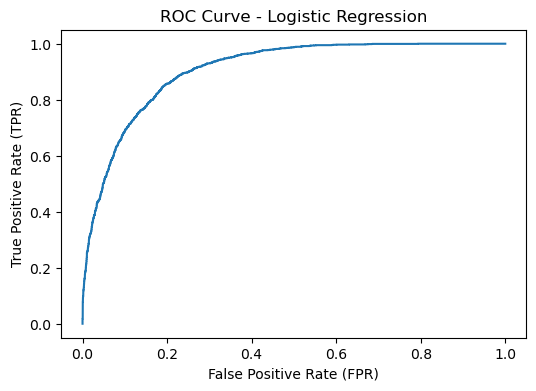

In [36]:
from sklearn.metrics import roc_auc_score,roc_curve

# Probability predictions
y_test_prob = logistic_regressor.predict_proba(X_test)[:,1]

lr_roc_auc_score = roc_auc_score(y_test, y_test_prob)
fpr_lr, tpr_lr,thresholds = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr_lr,tpr_lr,label=f'Logistic Regression (AUC = {lr_roc_auc_score:.3f})')
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - Logistic Regression")
plt.show()

# SVM ROC-AUC

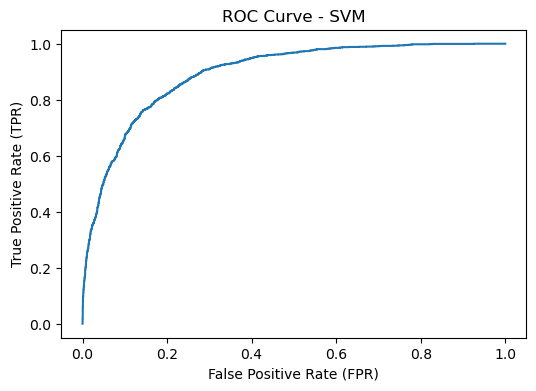

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Decision scores instead of probabilities
y_score_predict_svm = svc_classifier.decision_function(X_test)

svm_auc=roc_auc_score(y_test, y_score_predict_svm)
fpr_svm, tpr_svm, threshold = roc_curve(y_test,y_score_predict_svm)

plt.figure(figsize=(6,4))
plt.plot(fpr_svm, tpr_svm, label=f"Simplr Vector Metrics (AUC Score = {svm_auc:.3f}")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - SVM")
plt.show()

# KNN ROC-AUC

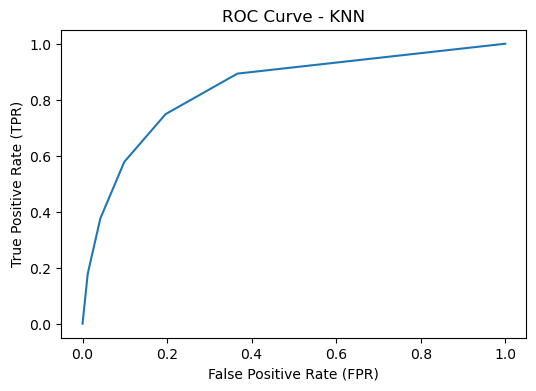

In [40]:
from  sklearn.metrics import roc_curve, roc_auc_score
y_predict_knn=knn_classifier.predict_proba(X_test)[:,1]
auc_knn=roc_auc_score(y_test,y_predict_knn)
fpr_knn, tpr_knn, thresholds = roc_curve(y_test, y_predict_knn) # False Positive Rate and True Positive Rate

plt.figure(figsize=(6,4))
plt.plot(fpr_knn, tpr_knn, label=f"ROC Curce - KNN (AOC Score {auc_knn:.3f})")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - KNN")
plt.show()

# Comparision of all 3 ROC Curves in a single plot

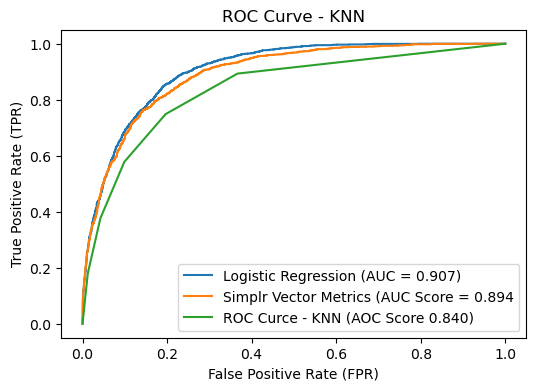

In [42]:
plt.figure(figsize=(6,4))
plt.plot(fpr_lr,tpr_lr,label=f'Logistic Regression (AUC = {lr_roc_auc_score:.3f})')

plt.plot(fpr_svm, tpr_svm, label=f"Simplr Vector Metrics (AUC Score = {svm_auc:.3f}")

plt.plot(fpr_knn, tpr_knn, label=f"ROC Curce - KNN (AOC Score {auc_knn:.3f})")

plt.legend()
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - KNN")
plt.show()